In [ ]:
#3:EXPLORATORY DATA ANALYSIS AND FRAME THE PROBLEM

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
client=pd.read_csv('./client_data (1).csv')
price=pd.read_csv('./price_data (1).csv')

In [4]:
client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [ ]:
client.describe()

In [6]:
client['churn'].sum()      #this many customer left

1419

In [7]:
print(client['id'].nunique())  #object

14606


In [8]:
client['num_years_antig'].max()

13

In [9]:
client['num_years_antig'].mean()

4.997809119539915

In [10]:
client['date_activ']=pd.to_datetime(client['date_activ'])
client['date_end']=pd.to_datetime(client['date_end'])
client['date_modif_prod']=pd.to_datetime(client['date_modif_prod'])
client['date_renewal']=pd.to_datetime(client['date_renewal'])

In [11]:
client.isna().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

In [ ]:
#So looks like we have 14606 customer id and  all of them are unique.

In [12]:
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [13]:
price.isna().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

In [14]:
print(price['id'].nunique())

16096


In [15]:
price['price_date']=pd.to_datetime(price['price_date'])

In [ ]:
price.describe()

In [ ]:
#Visuals-matplotlib-seaborn

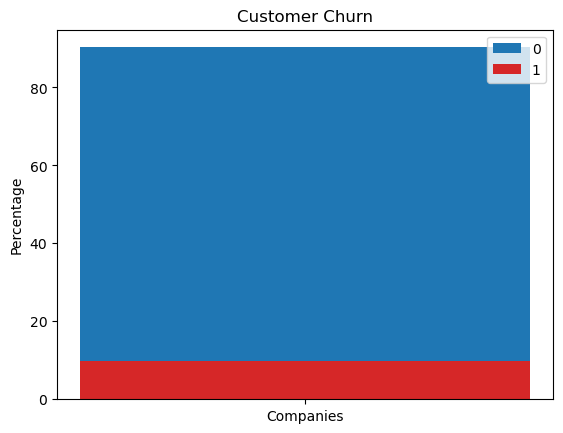

In [16]:
churndf = client[['id', 'churn']]
churndf.columns = ['Companies', 'churn']
churn_total = churndf.groupby(churndf['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
colors=['tab:blue','tab:red']
bottom=0

fig,ax=plt.subplots()
ax.bar(['Companies'], churn_percentage['Companies'], bottom=bottom,label=churn_percentage.index, color=colors)

ax.set_ylabel('Percentage')
ax.set_title('Customer Churn')

ax.legend()

plt.show()

In [ ]:
#Looking into channel sales and churns

In [17]:
client[['channel_sales']].nunique().sum()

8

In [18]:
channels=client[['id','churn','channel_sales']]
channels.head(1)

,id,churn,channel_sales
0,24011ae4ebbe3035111d65fa7c15bc57,1,foosdfpfkusacimwkcsosbicdxkicaua


In [19]:
#made separate churn datasets
churn1=channels[channels['churn']==1]
churn0=channels[channels['churn']==0]


In [20]:
churn0.groupby('channel_sales')['churn'].count()    #did not churn customer

channel_sales
MISSING                             3442
epumfxlbckeskwekxbiuasklxalciiuu       3
ewpakwlliwisiwduibdlfmalxowmwpci     818
fixdbufsefwooaasfcxdxadsiekoceaa       2
foosdfpfkusacimwkcsosbicdxkicaua    5934
lmkebamcaaclubfxadlmueccxoimlema    1740
sddiedcslfslkckwlfkdpoeeailfpeds      11
usilxuppasemubllopkaafesmlibmsdf    1237
Name: churn, dtype: int64

In [21]:
churn1.groupby('channel_sales')['churn'].count()    #chruned customer

channel_sales
MISSING                             283
ewpakwlliwisiwduibdlfmalxowmwpci     75
foosdfpfkusacimwkcsosbicdxkicaua    820
lmkebamcaaclubfxadlmueccxoimlema    103
usilxuppasemubllopkaafesmlibmsdf    138
Name: churn, dtype: int64

In [22]:
channels.groupby('channel_sales')['churn'].count()

channel_sales
MISSING                             3725
epumfxlbckeskwekxbiuasklxalciiuu       3
ewpakwlliwisiwduibdlfmalxowmwpci     893
fixdbufsefwooaasfcxdxadsiekoceaa       2
foosdfpfkusacimwkcsosbicdxkicaua    6754
lmkebamcaaclubfxadlmueccxoimlema    1843
sddiedcslfslkckwlfkdpoeeailfpeds      11
usilxuppasemubllopkaafesmlibmsdf    1375
Name: churn, dtype: int64

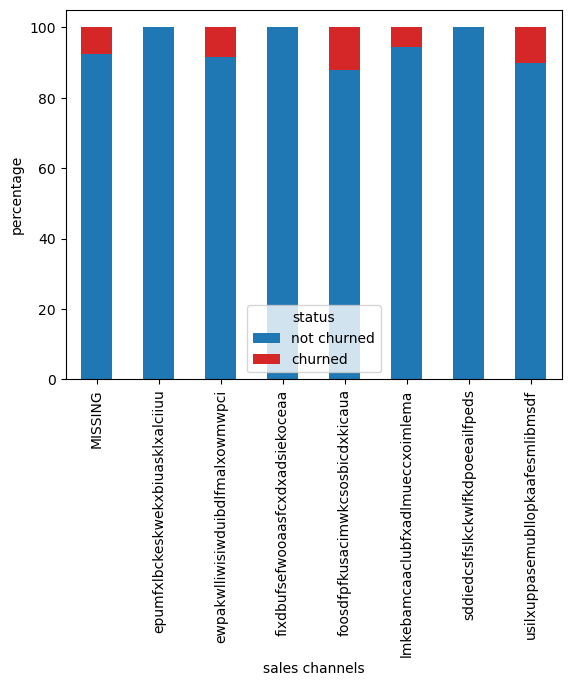

In [23]:
churn_pct=pd.crosstab(channels['channel_sales'], channels['churn'], normalize='index')*100
churn_pct.columns=['not churned','churned']

#calismadi bu percentage gosterme
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
#---------------

ax=churn_pct.plot(kind='bar', stacked=True, color=['tab:blue','tab:red'])
ax.legend(title='status')
ax.set_xlabel('sales channels')
ax.set_ylabel('percentage')

plt.show()


In [24]:
consumption=client[['id','channel_sales','cons_12m','cons_gas_12m','cons_last_month','has_gas','imp_cons',"forecast_cons_12m", "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m", "forecast_price_energy_off_peak","forecast_price_energy_peak", "forecast_price_pow_off_peak",'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin','pow_max','nb_prod_act', 'num_years_antig','origin_up','churn']]

In [ ]:
consumption.head(2)

In [25]:
retention=consumption.loc[consumption['churn']==0]
retention.head(5)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,has_gas,imp_cons,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,forecast_price_energy_peak,forecast_price_pow_off_peak,margin_gross_pow_ele,margin_net_pow_ele,net_margin,pow_max,nb_prod_act,num_years_antig,origin_up,churn
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,f,0.00,189.95,0,0.0,...,0.000000,44.311378,16.38,16.38,18.89,13.800,1,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,f,0.00,47.96,0,0.0,...,0.087899,44.311378,28.60,28.60,6.60,13.856,1,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,f,0.00,240.04,0,0.0,...,0.000000,44.311378,30.22,30.22,25.46,13.200,1,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,f,52.32,445.75,526,0.0,...,0.100015,40.606701,44.91,44.91,47.98,19.800,1,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,0
7,01495c955be7ec5e7f3203406785aae0,foosdfpfkusacimwkcsosbicdxkicaua,29552,0,1260,f,70.63,864.73,751,0.0,...,0.098837,40.606701,53.92,53.92,100.09,26.400,1,6,lxidpiddsbxsbosboudacockeimpuepw,0


In [26]:
Churn1=consumption.loc[consumption['churn']==1]
Churn1.head(5)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,has_gas,imp_cons,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,forecast_price_energy_peak,forecast_price_pow_off_peak,margin_gross_pow_ele,margin_net_pow_ele,net_margin,pow_max,nb_prod_act,num_years_antig,origin_up,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,t,0.00,0.00,0,0.0,...,0.098142,40.606701,25.44,25.44,678.99,43.648,2,3,lxidpiddsbxsbosboudacockeimpuepw,1
5,1aa498825382410b098937d65c4ec26d,usilxuppasemubllopkaafesmlibmsdf,8302,0,1998,f,181.21,796.94,1998,0.0,...,0.086131,45.308378,33.12,33.12,118.89,13.200,1,4,lxidpiddsbxsbosboudacockeimpuepw,1
6,7ab4bf4878d8f7661dfc20e9b8e18011,foosdfpfkusacimwkcsosbicdxkicaua,45097,0,0,f,0.00,8069.28,0,0.0,...,0.087538,44.311378,4.04,4.04,346.63,15.000,1,4,lxidpiddsbxsbosboudacockeimpuepw,1
25,389bbbe70248fbeecdf9bb1bd0d1da04,foosdfpfkusacimwkcsosbicdxkicaua,3584,0,322,f,32.61,379.83,322,0.0,...,0.100123,41.105201,57.72,57.72,38.76,23.100,1,5,lxidpiddsbxsbosboudacockeimpuepw,1
30,44e826a55734d0ca5eeafcae0e991a75,foosdfpfkusacimwkcsosbicdxkicaua,324,0,0,f,0.00,8.32,0,0.0,...,0.000000,44.311378,18.62,18.62,1.27,13.200,2,7,ldkssxwpmemidmecebumciepifcamkci,1


In [27]:
#Here we do bar chart with 2 dataset and laying them on each other

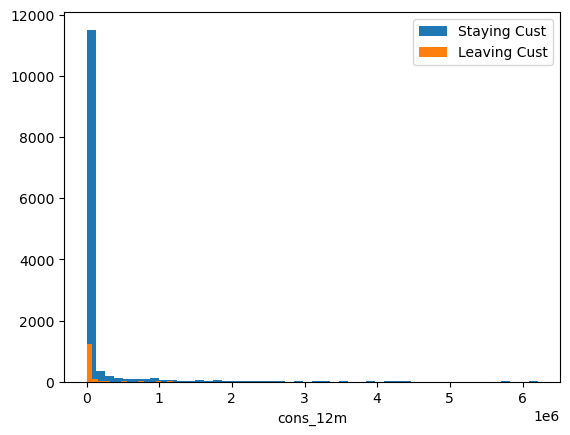

In [28]:
plt.hist(retention["cons_12m"],bins=50, label="Staying Cust")
plt.hist(Churn1["cons_12m"], bins=50, label="Leaving Cust")

plt.xlabel("cons_12m")
plt.legend()
plt.show()

In [29]:
#Stacked bar chart. using only 2 dataset (churn=1 and churn=0 df's)


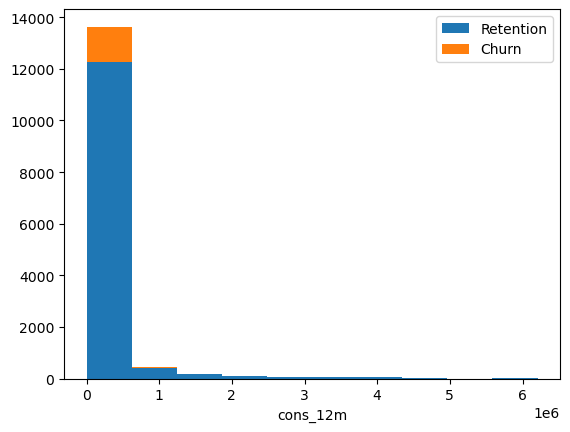

In [30]:
plt.hist([retention["cons_12m"], Churn1["cons_12m"]], label=["Retention", "Churn"], stacked=True)
plt.xlabel("cons_12m")
plt.legend()
plt.show()

In [31]:
columns=['id','channel_sales','cons_12m','cons_gas_12m','cons_last_month','has_gas','imp_cons',"forecast_cons_12m", "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m", "forecast_price_energy_off_peak","forecast_price_energy_peak", "forecast_price_pow_off_peak",'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin','pow_max','nb_prod_act','num_years_antig','origin_up']

In [32]:
sale_columns=['cons_12m','cons_gas_12m','cons_last_month']

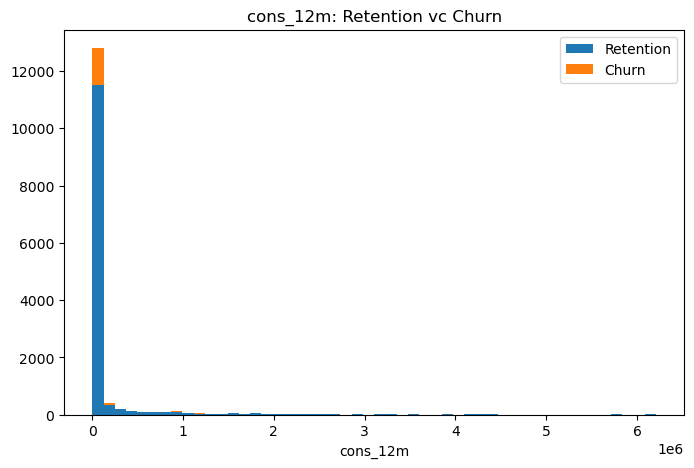

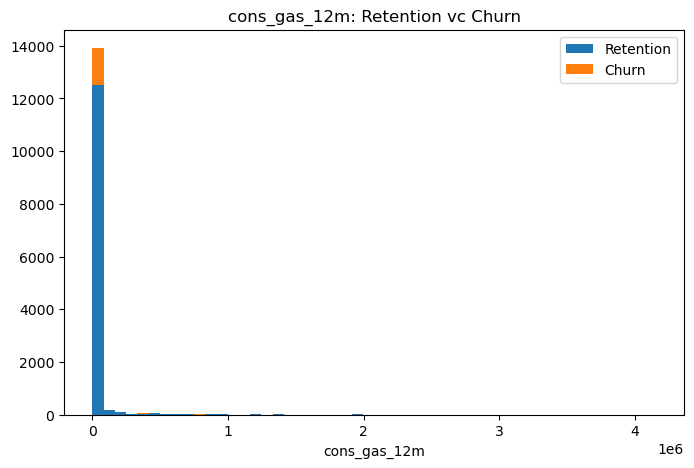

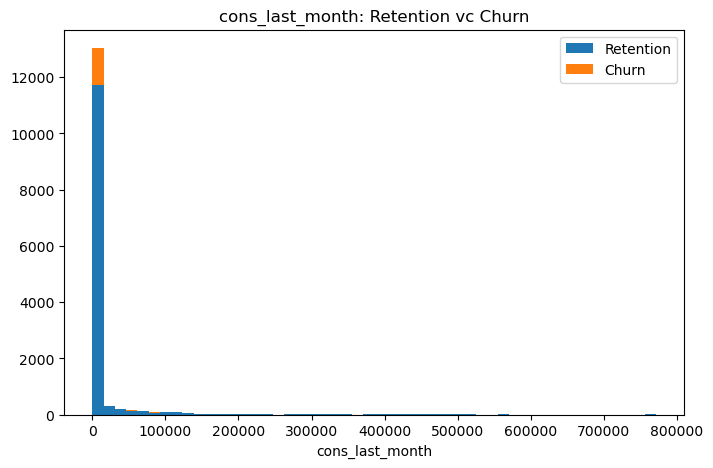

In [33]:
for col in sale_columns:
    plt.figure(figsize=(8,5))
    plt.hist([retention[col], Churn1[col]], label=["Retention", "Churn"],bins=50, stacked=True)

    plt.xlabel(col)
    plt.title(f"{col}: Retention vc Churn")
    plt.legend()
    plt.show()

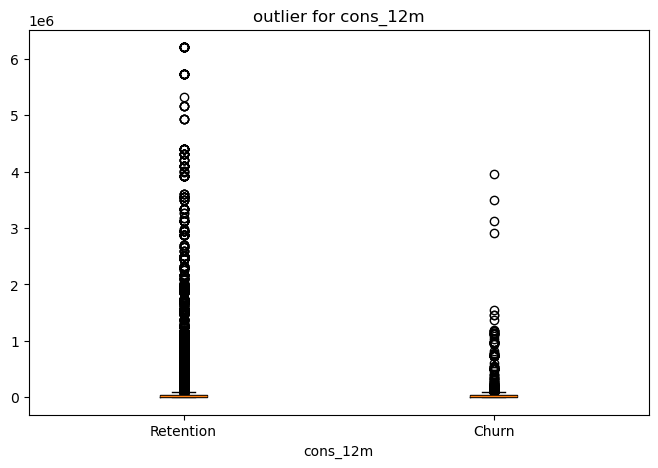

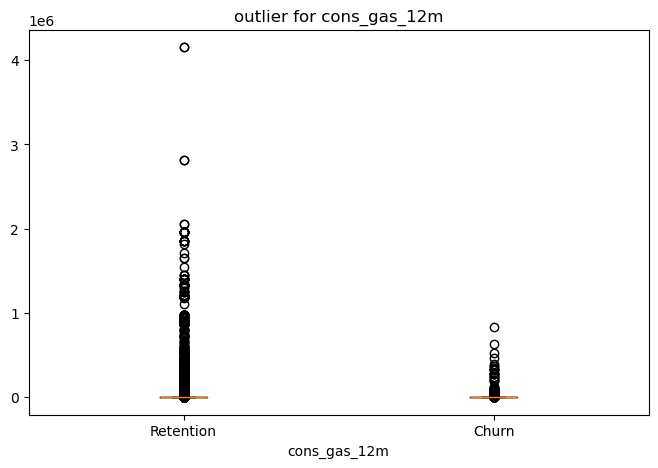

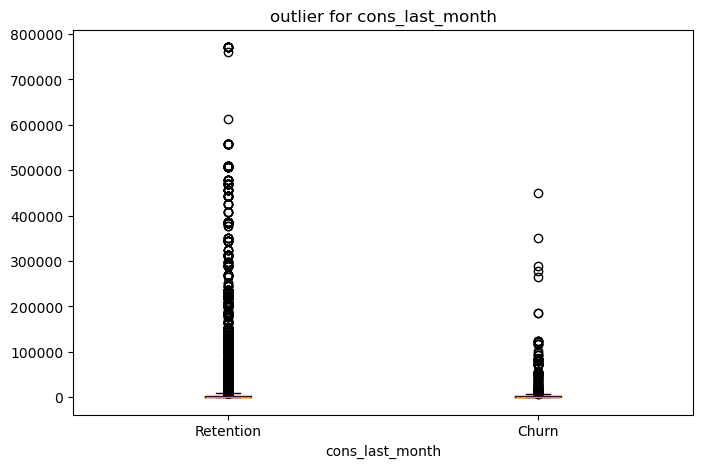

In [34]:
sale_columns = ['cons_12m', 'cons_gas_12m', 'cons_last_month']
for col in sale_columns:
    plt.figure(figsize=(8, 5))
    plt.boxplot([retention[col], Churn1[col]], labels=["Retention", "Churn"])

    plt.xlabel(col)
    plt.title(f"outlier for {col}")
    plt.show()

In [35]:
forecast_columns=["forecast_cons_12m", "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m", "forecast_price_energy_off_peak","forecast_price_energy_peak", "forecast_price_pow_off_peak"]

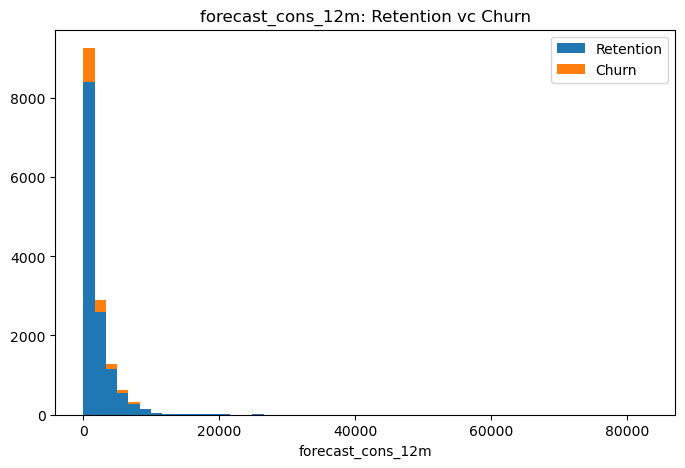

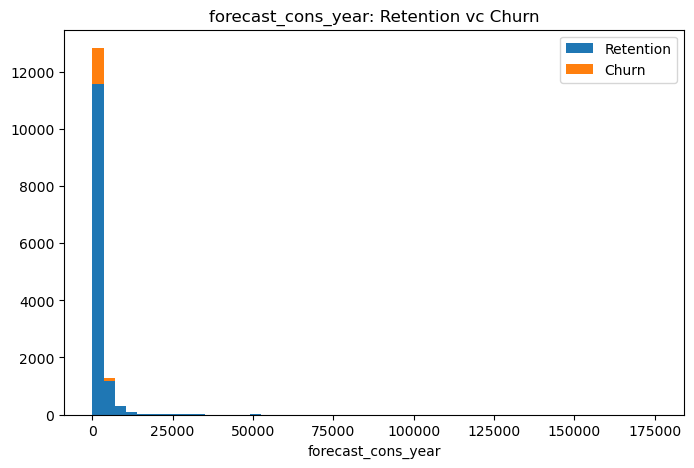

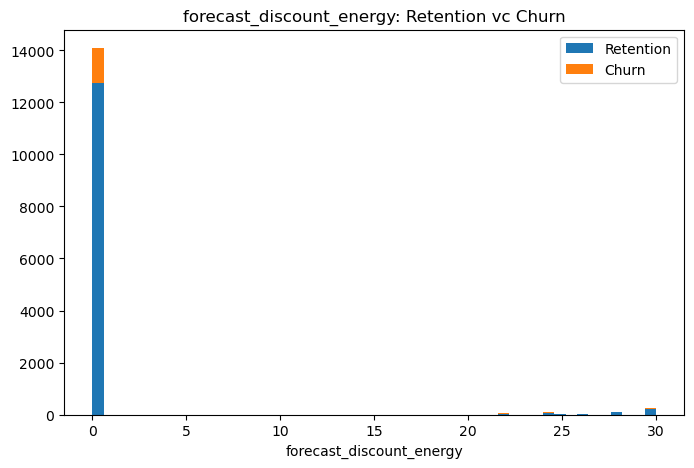

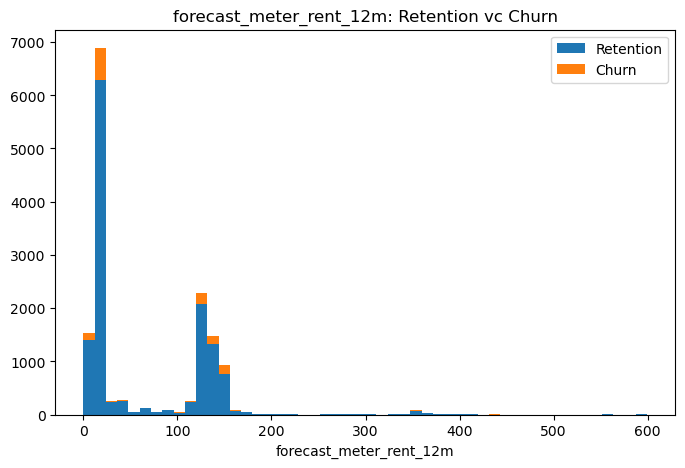

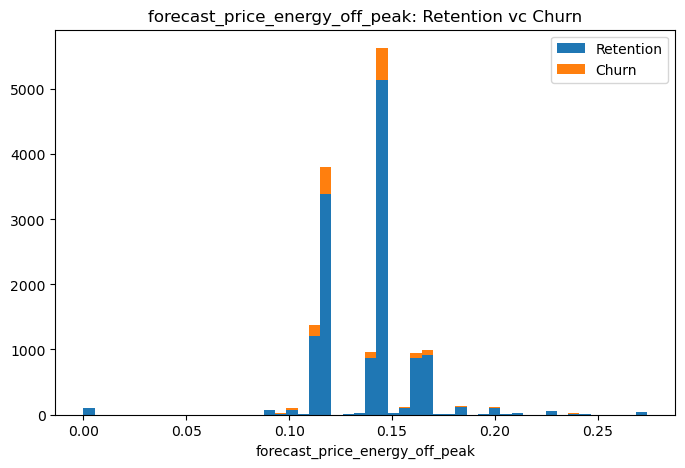

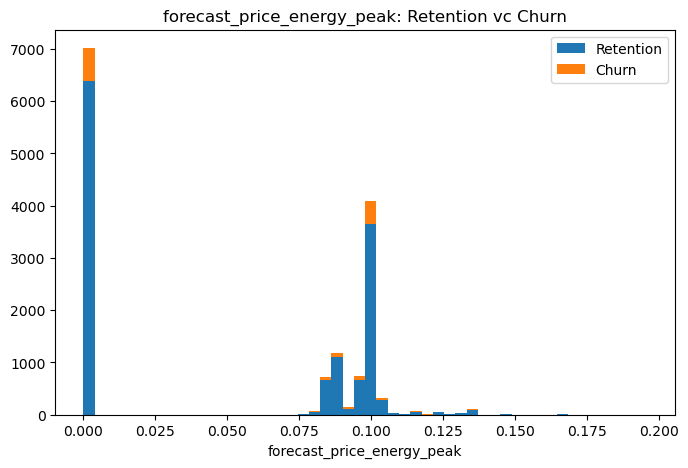

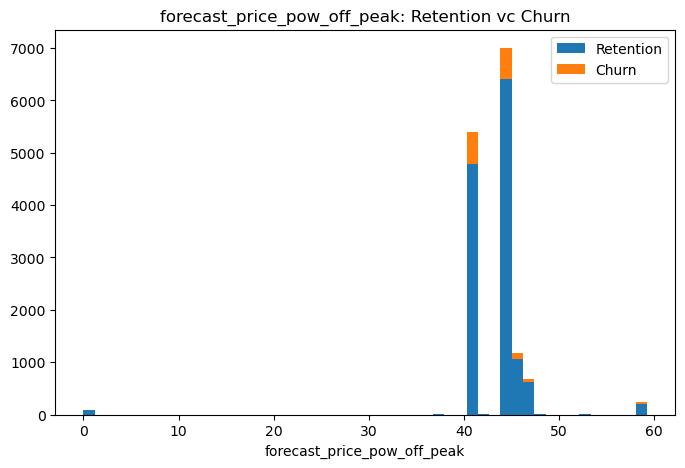

In [36]:
for col in forecast_columns:
    plt.figure(figsize=(8,5))
    plt.hist([retention[col], Churn1[col]], label=["Retention", "Churn"],bins=50, stacked=True)

    plt.xlabel(col)
    plt.title(f"{col}: Retention vc Churn")
    plt.legend()
    plt.show()

In [37]:
margin_columns=['margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']

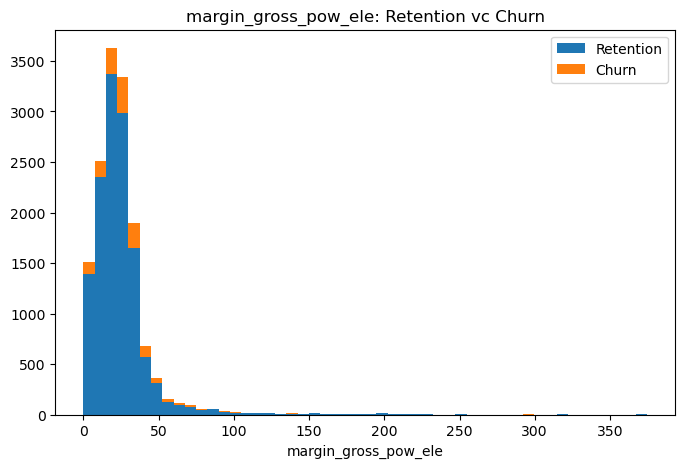

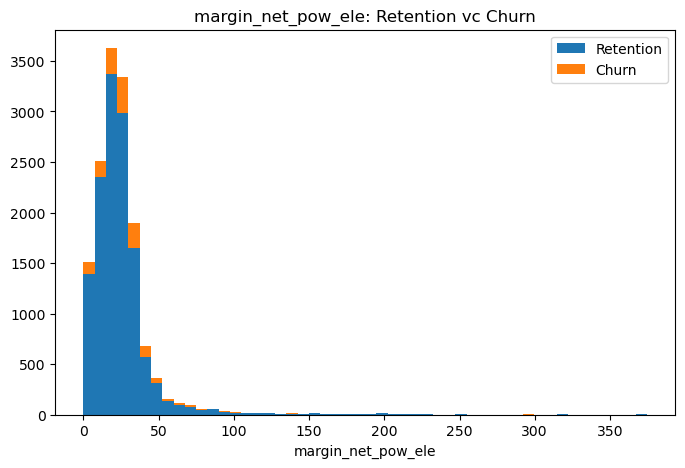

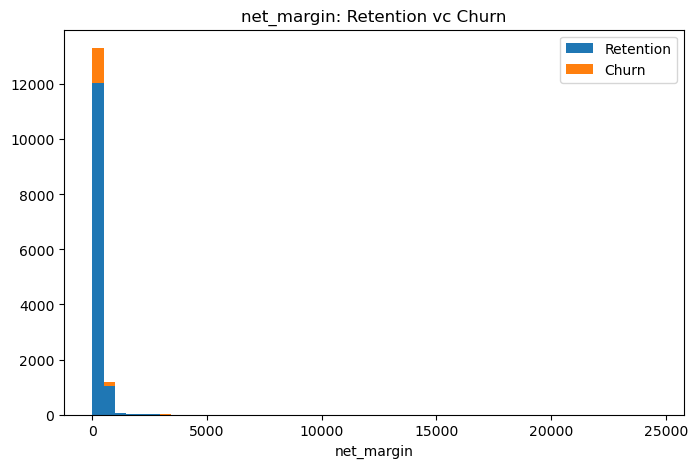

In [38]:
for col in margin_columns:
    plt.figure(figsize=(8,5))
    plt.hist([retention[col], Churn1[col]], label=["Retention", "Churn"],bins=50, stacked=True)

    plt.xlabel(col)
    plt.title(f"{col}: Retention vc Churn")
    plt.legend()
    plt.show()

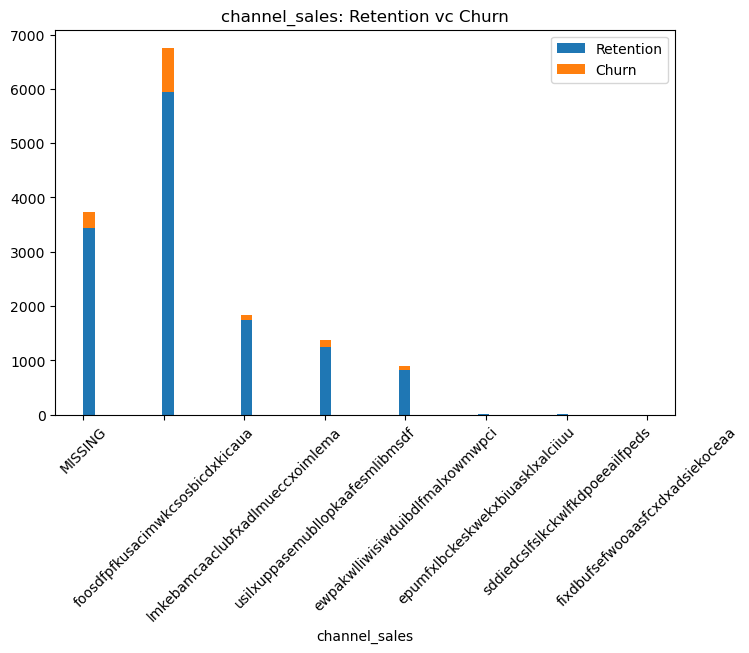

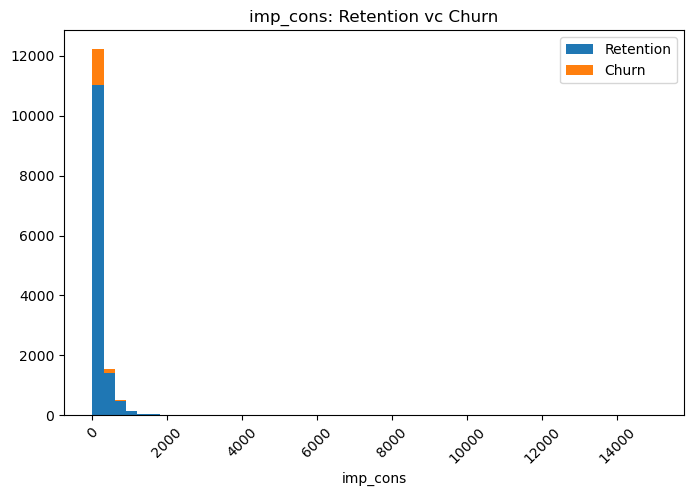

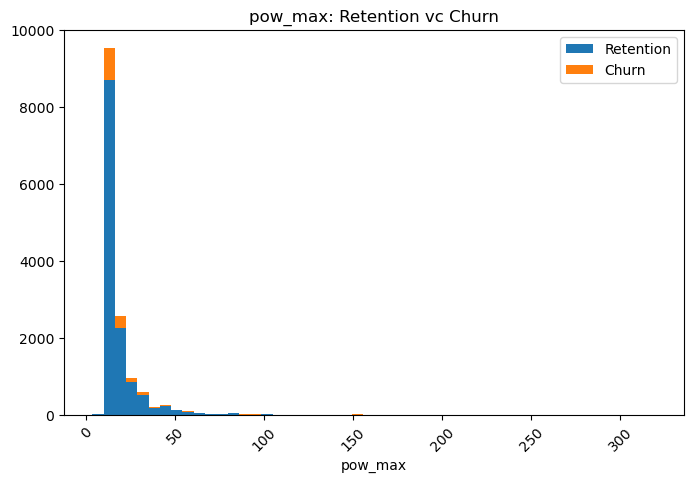

In [39]:
columnN=['channel_sales','imp_cons','pow_max' ]
for col in columnN:
    plt.figure(figsize=(8,5))
    plt.hist([retention[col], Churn1[col]], label=["Retention", "Churn"],bins=50, stacked=True)

    plt.xlabel(col)
    plt.title(f"{col}: Retention vc Churn")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

In [40]:
retention['margin_gross_pow_ele'].describe()

count    13187.000000
mean        23.929863
std         19.359021
min          0.000000
25%         13.860000
50%         21.480000
75%         29.640000
max        374.640000
Name: margin_gross_pow_ele, dtype: float64

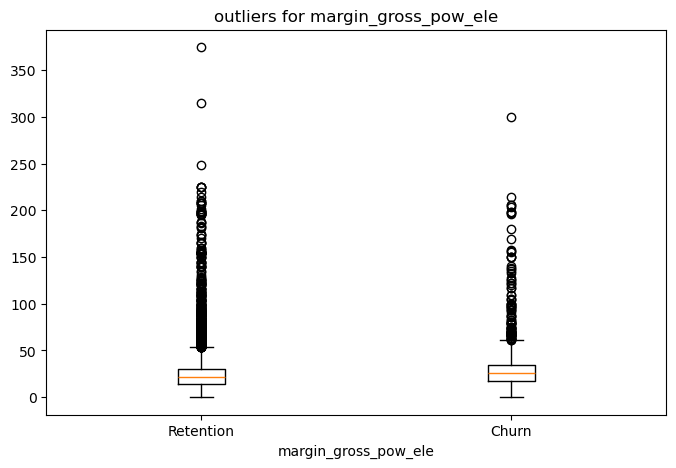

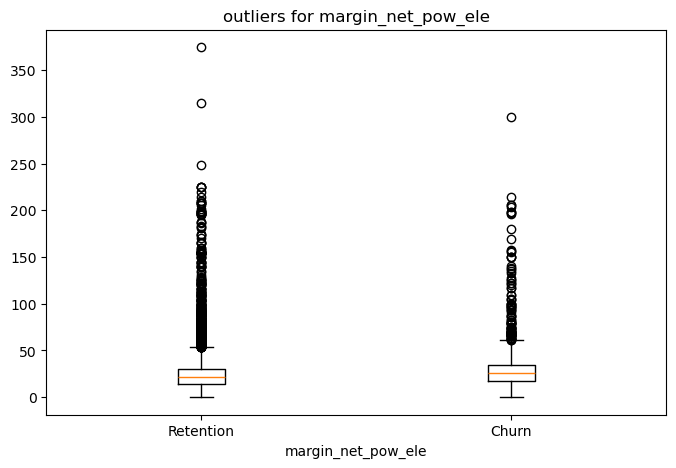

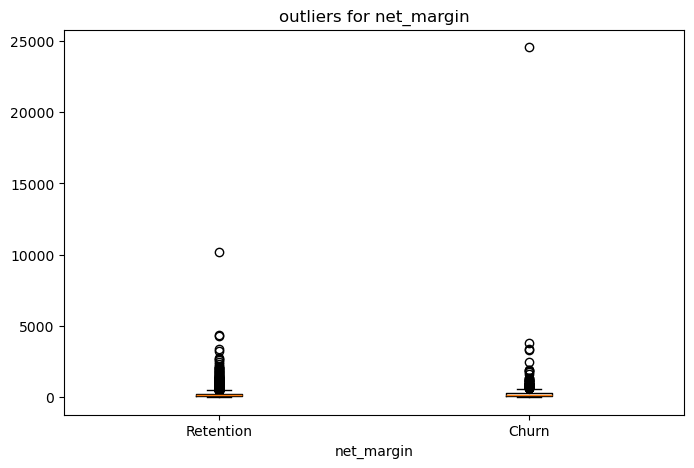

In [41]:
margin_columns = ['margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']
for col in margin_columns:
    plt.figure(figsize=(8, 5))
    plt.boxplot([retention[col], Churn1[col]], labels=["Retention", "Churn"])

    plt.xlabel(col)
    plt.title(f"outliers for {col}")
    plt.show()

In [42]:
column_counts=['nb_prod_act','num_years_antig','origin_up','has_gas']

In [43]:
contract_type = consumption[['id','nb_prod_act','num_years_antig','origin_up','has_gas', 'churn']]
gas = contract_type.groupby([contract_type['churn'], contract_type['has_gas']])['id'].count().unstack(level=0)
prod_act=contract_type.groupby([contract_type['churn'], contract_type['nb_prod_act']])['id'].count().unstack(level=1)
antiq=contract_type.groupby([contract_type['churn'], contract_type['num_years_antig']])['id'].count().unstack(level=1)
original=contract_type.groupby([contract_type['churn'], contract_type['origin_up']])['id'].count().unstack(level=1)

gas.head()
prod_act.head()
original.head()
antiq.head()

num_years_antig,1,2,3,4,5,6,7,8,9,10,11,12,13
churn,,,,,,,,,,,,,
0,1.0,8.0,2104.0,3510.0,2117.0,4430.0,467.0,98.0,91.0,77.0,173.0,99.0,12.0
1,NaN,3.0,329.0,472.0,200.0,339.0,42.0,5.0,1.0,4.0,12.0,11.0,1.0


<Axes: xlabel='churn'>

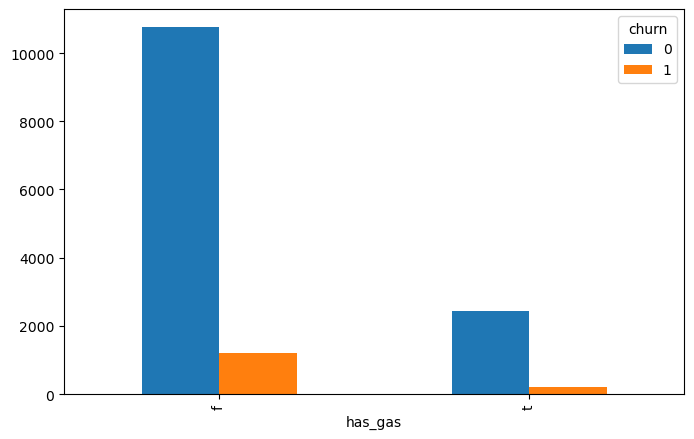

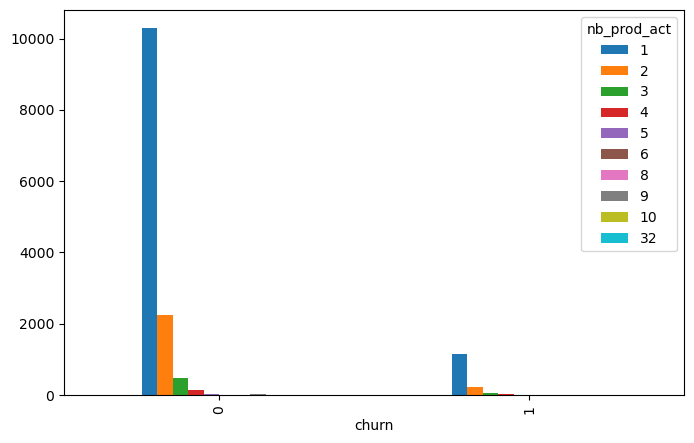

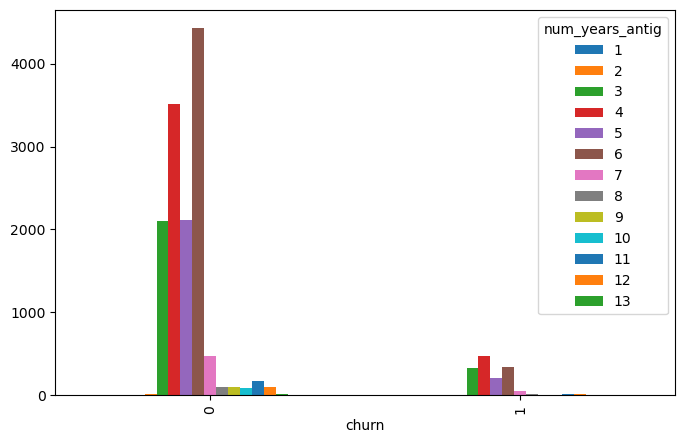

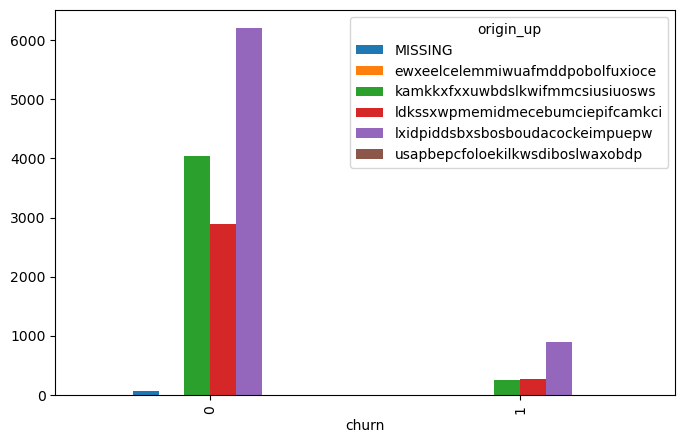

In [44]:
gas.plot(kind='bar',figsize=(8,5))
prod_act.plot(kind='bar', figsize=(8,5))
antiq.plot(kind='bar', figsize=(8,5))
original.plot(kind='bar', figsize=(8,5))



In [ ]:
#4:FEATURE ENGINEERING TO TEST HYPOTHESES=IS PRICE TO PROBLEM?)
#adding,deleting,mutating,combining of dataset to improve for ML to get better performance and accuracy

In [45]:
price['price_date'].min()

Timestamp('2015-01-01 00:00:00')

In [46]:
price['price_date'].max()

Timestamp('2015-12-01 00:00:00')

In [49]:
price.describe()

In [50]:
# Group off-peak prices by companies and month
monthly_price_by_id = price.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

In [ ]:
monthly_price_by_id.head()   #here we are just getting means of id's and price's group

In [ ]:
#if data is not ordered this will not work---> short_values('id','price_date') then this will work. This data is sorted.

In [51]:
jan_prices=monthly_price_by_id.groupby('id').first().reset_index()      #get 1 row for each id(january)

In [52]:
dec_prices=monthly_price_by_id.groupby('id').last().reset_index()
dec_prices.head()      #get last row for each id(december)

,id,price_date,price_off_peak_var,price_off_peak_fix
0,0002203ffbb812588b632b9e628cc38d,2015-12-01,0.119906,40.728885
1,0004351ebdd665e6ee664792efc4fd13,2015-12-01,0.143943,44.444710
2,0010bcc39e42b3c2131ed2ce55246e3c,2015-12-01,0.201280,45.944710
3,0010ee3855fdea87602a5b7aba8e42de,2015-12-01,0.113068,40.728885
4,00114d74e963e47177db89bc70108537,2015-12-01,0.145440,44.266930


In [53]:
diff=pd.merge(dec_prices, jan_prices, on='id')
diff.head()

,id,price_date_x,price_off_peak_var_x,price_off_peak_fix_x,price_date_y,price_off_peak_var_y,price_off_peak_fix_y
0,0002203ffbb812588b632b9e628cc38d,2015-12-01,0.119906,40.728885,2015-01-01,0.126098,40.565969
1,0004351ebdd665e6ee664792efc4fd13,2015-12-01,0.143943,44.444710,2015-01-01,0.148047,44.266931
2,0010bcc39e42b3c2131ed2ce55246e3c,2015-12-01,0.201280,45.944710,2015-01-01,0.150837,44.444710
3,0010ee3855fdea87602a5b7aba8e42de,2015-12-01,0.113068,40.728885,2015-01-01,0.123086,40.565969
4,00114d74e963e47177db89bc70108537,2015-12-01,0.145440,44.266930,2015-01-01,0.149434,44.266931


In [54]:
diff=diff.rename(columns={'price_off_peak_var_x': 'dec1', 'price_off_peak_fix_x':'dec2', 'price_off_peak_var_y':'jan1','price_off_peak_fix_y': 'jan2'}).drop(columns='price_date_y')

In [55]:
diff=diff.rename(columns={'price_date_x':'price_date'})
diff.head()

,id,price_date,dec1,dec2,jan1,jan2
0,0002203ffbb812588b632b9e628cc38d,2015-12-01,0.119906,40.728885,0.126098,40.565969
1,0004351ebdd665e6ee664792efc4fd13,2015-12-01,0.143943,44.444710,0.148047,44.266931
2,0010bcc39e42b3c2131ed2ce55246e3c,2015-12-01,0.201280,45.944710,0.150837,44.444710
3,0010ee3855fdea87602a5b7aba8e42de,2015-12-01,0.113068,40.728885,0.123086,40.565969
4,00114d74e963e47177db89bc70108537,2015-12-01,0.145440,44.266930,0.149434,44.266931


In [56]:
diff['off_peak_diff1']=diff['dec1']-diff['jan1']
diff['off_peak_diff2']=diff['dec2']-diff['jan2']
diff.head()

,id,price_date,dec1,dec2,jan1,jan2,off_peak_diff1,off_peak_diff2
0,0002203ffbb812588b632b9e628cc38d,2015-12-01,0.119906,40.728885,0.126098,40.565969,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,2015-12-01,0.143943,44.444710,0.148047,44.266931,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,2015-12-01,0.201280,45.944710,0.150837,44.444710,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,2015-12-01,0.113068,40.728885,0.123086,40.565969,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,2015-12-01,0.145440,44.266930,0.149434,44.266931,-0.003994,-0.000001


In [57]:
newdf=diff[['id','off_peak_diff1','off_peak_diff2']]
newdf.head()

,id,off_peak_diff1,off_peak_diff2
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [58]:
newdf.groupby('id').agg({'off_peak_diff1': 'mean','off_peak_diff2':'mean'})

,off_peak_diff1,off_peak_diff2
id,,
0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
00114d74e963e47177db89bc70108537,-0.003994,-0.000001
...,...,...
ffef185810e44254c3a4c6395e6b4d8a,-0.050232,-0.335085
fffac626da707b1b5ab11e8431a4d0a2,-0.003778,0.177779
fffc0cacd305dd51f316424bbb08d1bd,-0.001760,0.164916


In [ ]:
#Feature engineering for clean data has 44 columns.

In [59]:
clean=pd.read_csv('clean_data_after_eda.csv')

In [ ]:
clean.head()

In [60]:
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [61]:
clean['date_activ']=pd.to_datetime(clean['date_activ'])
clean['date_end']=pd.to_datetime(clean['date_end'])
clean['date_modif_prod']=pd.to_datetime(clean['date_modif_prod'])
clean['date_renewal']=pd.to_datetime(clean['date_renewal'])

In [62]:
clean=pd.merge(clean, newdf, on='id')
clean.head(1)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,off_peak_diff1,off_peak_diff2
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,0.000908,2.086294,99.530517,44.235794,2.086425,99.530558,44.236702,1,0.020057,3.700961


In [63]:
mean_price=price.groupby('id').agg({'price_off_peak_var':'mean', 'price_peak_var':'mean','price_mid_peak_var':'mean','price_off_peak_fix':'mean','price_peak_fix':'mean','price_mid_peak_fix':'mean'}).reset_index()

In [64]:
mean_price.head()

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000


In [65]:
mean_price['price_off_peek_var_peek_var_mean_diff']=mean_price['price_off_peak_var']-mean_price['price_peak_var']
mean_price['price_off_peek_var_mid_mean_var_diff']=mean_price['price_off_peak_var']-mean_price['price_mid_peak_var']
mean_price['price_peek_var_mid_peak_var_mean_diff']=mean_price['price_peak_var']-mean_price['price_mid_peak_var']
mean_price['price_off_peak_fix_peak_fix_mean_diff']=mean_price['price_off_peak_fix']-mean_price['price_peak_fix']
mean_price['price_peak_fix_mid_peak_fix_mean_diff']=mean_price['price_peak_fix']-mean_price['price_mid_peak_fix']
mean_price['price_off_peak_fix_mid_peak_fix_mean_diff']=mean_price['price_off_peak_fix']-mean_price['price_mid_peak_fix']

In [66]:
mean_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16096 entries, 0 to 16095
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         16096 non-null  object 
 1   price_off_peak_var                         16096 non-null  float64
 2   price_peak_var                             16096 non-null  float64
 3   price_mid_peak_var                         16096 non-null  float64
 4   price_off_peak_fix                         16096 non-null  float64
 5   price_peak_fix                             16096 non-null  float64
 6   price_mid_peak_fix                         16096 non-null  float64
 7   price_off_peek_var_peek_var_mean_diff      16096 non-null  float64
 8   price_off_peek_var_mid_mean_var_diff       16096 non-null  float64
 9   price_peek_var_mid_peak_var_mean_diff      16096 non-null  float64
 10  price_off_peak_fix_pea

In [67]:
Columns=['id','price_off_peek_var_peek_var_mean_diff','price_off_peek_var_mid_mean_var_diff','price_peek_var_mid_peak_var_mean_diff','price_off_peak_fix_peak_fix_mean_diff','price_peak_fix_mid_peak_fix_mean_diff','price_off_peak_fix_mid_peak_fix_mean_diff']
clean=pd.merge(clean,mean_price[Columns], on='id')
clean.head(1)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak,churn,off_peak_diff1,off_peak_diff2,price_off_peek_var_peek_var_mean_diff,price_off_peek_var_mid_mean_var_diff,price_peek_var_mid_peak_var_mean_diff,price_off_peak_fix_peak_fix_mean_diff,price_peak_fix_mid_peak_fix_mean_diff,price_off_peak_fix_mid_peak_fix_mean_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,44.236702,1,0.020057,3.700961,0.024038,0.058257,0.034219,18.590255,7.45067,26.040925


In [70]:
montly_price_means=price.groupby(['id','price_date']).agg({
    'price_off_peak_var':'mean',
    'price_peak_var':'mean',
    'price_mid_peak_var':'mean',
    'price_off_peak_fix':'mean',
    'price_peak_fix':'mean',
    'price_mid_peak_fix':'mean'
}).reset_index()


In [71]:
montly_price_means['montly_price_off_peak_peek_var']=montly_price_means['price_off_peak_var']-montly_price_means['price_peak_var']
montly_price_means['montly_price_off_peak_mid_peak_var']=montly_price_means['price_off_peak_var']-montly_price_means['price_mid_peak_var']
montly_price_means['montly_price_peak_var_mid_peak_var']=montly_price_means['price_peak_var']-montly_price_means['price_mid_peak_var']
montly_price_means['montly_price_off_peak_peek_fix']=montly_price_means['price_off_peak_fix']-montly_price_means['price_peak_fix']
montly_price_means['montly_price_off_peak_mid_peek_fix']=montly_price_means['price_off_peak_fix']-montly_price_means['price_mid_peak_fix']
montly_price_means['montly_price_peak_mid_peek_fix']=montly_price_means['price_peak_fix']-montly_price_means['price_mid_peak_fix']


In [ ]:
montly_price_means.head(1)

In [ ]:
#max of montly periodcale difference

In [72]:
max_diff_montly_price_periods=montly_price_means.groupby('id').agg({
    'montly_price_off_peak_peek_var':'max',
    'montly_price_off_peak_mid_peak_var':'max',
    'montly_price_peak_var_mid_peak_var':'max',
    'montly_price_off_peak_peek_fix':'max',
    'montly_price_off_peak_mid_peek_fix':'max',
    'montly_price_peak_mid_peek_fix':'max'
}).reset_index().rename({'montly_price_off_peak_peek_var':'montly_max_price_off_peak_peek_var',
               'montly_price_off_peak_mid_peak_var':'montly_max_price_off_peak_mid_peak_var','montly_price_peak_var_mid_peak_var':'montly_max_price_peak_var_mid_peak_var',
                'montly_price_off_peak_peek_fix':'montly_max_price_off_peak_peek_fix',
                'montly_price_off_peak_mid_peek_fix':'montly_max_price_off_peak_mid_peek_fix',
                'montly_price_peak_mid_peek_fix':'montly_max_price_peak_mid_peek_fix'
})

In [ ]:
max_diff_montly_price_periods.head(1)

In [75]:
clean=pd.merge(clean,max_diff_montly_price_periods, on='id')
clean.head(1)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,price_peek_var_mid_peak_var_mean_diff,price_off_peak_fix_peak_fix_mean_diff,price_peak_fix_mid_peak_fix_mean_diff,price_off_peak_fix_mid_peak_fix_mean_diff,montly_price_off_peak_peek_var,montly_price_off_peak_mid_peak_var,montly_price_peak_var_mid_peak_var,montly_price_off_peak_peek_fix,montly_price_off_peak_mid_peek_fix,montly_price_peak_mid_peek_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,0.034219,18.590255,7.45067,26.040925,0.06055,0.146033,0.085483,44.26693,44.26693,8.145775


In [ ]:
#TENNER= HOW LONG A CUSTOMER WAS WITH US.     (.dt.days//356)

In [77]:
clean['tenner']=clean['date_end']-clean['date_activ']

In [78]:
clean['tenner']=clean['tenner'].dt.days//365

In [79]:
tenner_churn=clean.groupby('tenner').agg({'churn':'sum'}).sort_values(by='tenner', ascending=False).reset_index()

Text(0.5, 0, 'Tenner Duration(Year)')

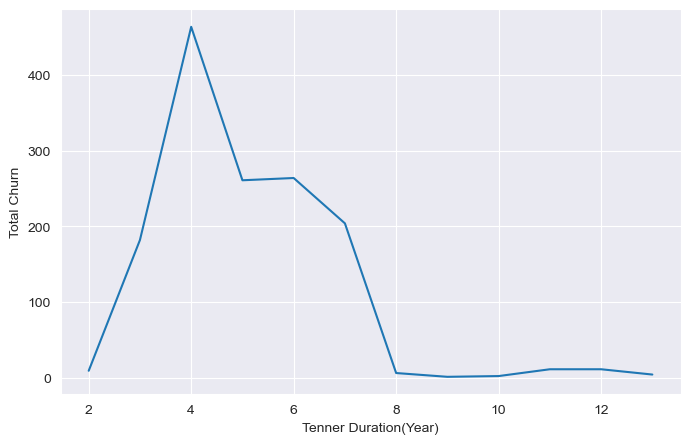

In [81]:
plt.figure(figsize=(8,5))
plt.plot(tenner_churn['tenner'], tenner_churn['churn'] )
plt.ylabel('Total Churn')
plt.xlabel('Tenner Duration(Year)')

In [ ]:
#This shows that long turn customers are less likely to leave powerco then short term companies.GET MONTHS SEP,2026 GIBI CUNKU #DATETIMES ARE NOT USEFUL FOR SEEING CUSTOMER IF THEY STAY OR LEAVE WHEN THEIR CONTRACT IS OVER.

In [82]:
from datetime import datetime

In [83]:
reference_date =datetime(2016,1,1)

columns=['date_activ','date_end','date_modif_prod','date_renewal']
newcals=['mont_activ','month_end','month_modif_prod','month_renewal']

for column,newcal in zip(columns,newcals):
    year_diff=reference_date.year-clean[column].dt.year
    month_diff=reference_date.month-clean[column].dt.month
    months=year_diff*12+month_diff
    months-=(reference_date.day<clean[column].dt.day).astype(int)
    clean[newcal]=months



In [84]:
clean['month_end']=-clean['month_end']   #I got rid of negative sign

In [85]:
clean=clean.drop(columns=['date_activ','date_end','date_modif_prod','date_renewal'])

In [86]:
clean['has_gas']=clean['has_gas'].map({'t':1, 'f':0})     #.replace([t,f],[1,0]) will work too.

In [87]:
clean.groupby(['churn']).agg({'has_gas':'mean'})

,has_gas
churn,
0,0.184576
1,0.152925


In [88]:
#Transform categorigal data to 0,1

In [89]:
# channel sales , origin up---------> create get.dummies()     *****<100

In [90]:
clean.groupby(['channel_sales']).agg({'channel_sales':'count'})

,channel_sales
channel_sales,
MISSING,3725
epumfxlbckeskwekxbiuasklxalciiuu,3
ewpakwlliwisiwduibdlfmalxowmwpci,893
fixdbufsefwooaasfcxdxadsiekoceaa,2
foosdfpfkusacimwkcsosbicdxkicaua,6754
lmkebamcaaclubfxadlmueccxoimlema,1843
sddiedcslfslkckwlfkdpoeeailfpeds,11
usilxuppasemubllopkaafesmlibmsdf,1375


In [ ]:
clean['origin_up'].value_counts()

In [91]:
column_dums=['origin_up','channel_sales']
for column in column_dums:
    counts=clean[column].value_counts()
    rare=counts[counts<100].index     #because here index is the categories in the column
    clean=clean[~clean[column].isin(rare)]
clean=pd.get_dummies(clean, columns=column_dums, dtype=int)

In [ ]:
''' Transforming numerical data log bcause it had positive skewness
Skewness isn't always a bad thing, but as a rule of thumb it is good practice to treat highly skewed variables to make them more normally distributed. This can also increase the speed at which predictive models are able to converge to the best solution.
'''

In [92]:
import numpy as np
skewed_cols = [
    'cons_12m',
    'cons_gas_12m',
    'cons_last_month',
    'forecast_cons_12m',
    'forecast_cons_year',
    'forecast_discount_energy',
    'forecast_meter_rent_12m',
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak',
    'forecast_price_pow_off_peak'
]

print("Before log transform:")
print(clean[skewed_cols].describe())

clean[skewed_cols] = np.log10(clean[skewed_cols] + 1)

print("After log transform:")
print(clean[skewed_cols].describe())

Before log transform:
           cons_12m  cons_gas_12m  cons_last_month  forecast_cons_12m  \
count  1.452300e+04  1.452300e+04     14523.000000       14523.000000   
mean   1.596212e+05  2.817860e+04     16128.206775        1864.602406   
std    5.744984e+05  1.633748e+05     64479.038492        2357.910162   
min    0.000000e+00  0.000000e+00         0.000000           0.000000   
25%    5.675500e+03  0.000000e+00         0.000000         494.580000   
50%    1.411800e+04  0.000000e+00       794.000000        1112.030000   
75%    4.076850e+04  0.000000e+00      3383.000000        2399.165000   
max    6.207104e+06  4.154590e+06    771203.000000       82902.830000   

       forecast_cons_year  forecast_discount_energy  forecast_meter_rent_12m  \
count        14523.000000              14523.000000             14523.000000   
mean          1395.045996                  0.964539                63.087963   
std           3221.817714                  5.102359                66.118354   


In [93]:
#Correlation= we will check if some of the column are correlated and predictive models works best if features are not correlated.so we will remove the correlated columns .

In [94]:
correlation=clean.drop(columns=['id']).corr()

In [ ]:
plt.figure(figsize=(50,50))
sns.heatmap(correlation,
            xticklabels=correlation.columns.values,
            yticklabels=correlation.columns.values,
            annot=True,
            annot_kws={'size':12}
            )

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [ ]:
#I will load the correlation as pgn because it's too big

In [ ]:
clean=clean.drop(columns=['num_years_antig', 'forecast_cons_year'])     #high correlation

In [ ]:
'''Machine learning'''